# Mini project
Marko Tacer - UL, UT

for saving the GIF files just uncomment the two # lines

In [157]:
import numpy as np
import matplotlib.pyplot as plt

## Description of Collisions

Generally about collisions:

### Plastic Collision
In a plastic collision, kinetic energy is not conserved, and the colliding objects stick together after the collision. This typically occurs when the colliding objects deform upon impact, such as in a car crash.

The coefficient of restitution $\textit{e}$ for a plastic collision is 0, indicating that the relative velocity of the objects after the collision is zero.

### Elastic Collision
In an elastic collision, kinetic energy is conserved, and the colliding objects rebound after the collision. This occurs when the colliding objects do not deform upon impact and no kinetic energy is lost.

The coefficient of restitution $\textit{e}$ for an elastic collision is 1, indicating that the relative velocity of the objects after the collision is equal to the relative velocity before the collision.

The coefficient of restitution $e$ is defined as:

$$
e = \frac{{\text{{relative velocity after collision}}}}{{\text{{relative velocity before collision}}}}
$$

For a two-dimensional elastic collision between two objects of masses \( m_1 \) and \( m_2 \) with initial velocities \( v_{1i} \) and \( v_{2i} \) along the x-axis, the final velocities \( v_{1f} \) and \( v_{2f} \) can be calculated using the equations:

$$
v_{1f} = \frac{{m_1 - m_2}}{{m_1 + m_2}} v_{1i} + \frac{{2m_2}}{{m_1 + m_2}} v_{2i}
$$

$$
v_{2f} = \frac{{2m_1}}{{m_1 + m_2}} v_{1i} + \frac{{m_2 - m_1}}{{m_1 + m_2}} v_{2i}
$$


Defining the basic arrays, timeframe and gravitational acceleration.

In [158]:
t = np.linspace(0, 60, 60001)
g = 9.81

IC = [0, 300, 50, 0]
# Bullet
bullet_mass = 0.02
bullet_y = np.zeros(len(t))
bullet_vy = np.zeros(len(t))
bullet_ay = np.zeros(len(t))

# Initial conditions
bullet_y[0] = IC[0]
bullet_vy[0] = IC[1]
bullet_ay[:] = -g

# Block of wood
block_mass = 2.0
block_length = 0.3
block_y = np.zeros(len(t))
block_vy = np.zeros(len(t))
block_ay = np.zeros(len(t))

# Initial conditions
block_y[:] = IC[2]
block_vy[0] = IC[3]
block_ay[:] = -g

## Perfectly elastic collision 1D

For a perfectly elastic collision among the conservation of linear momentum there is also a conservation of kinetic energy

$$
e = \frac{{\text{{relative velocity after collision}}}}{{\text{{relative velocity before collision}}}} = 1
$$

For a two-dimensional elastic collision between two objects of masses $m_1$ and $m_2$ with initial velocities $v_{1i}$ and $v_{2i}$ along the x-axis, the final velocities $v_{1f}$ and $v_{2f}$ can be calculated using the equations:

$$
v_{1f} = \frac{{m_1 - m_2}}{{m_1 + m_2}} v_{1i} + \frac{{2m_2}}{{m_1 + m_2}} v_{2i}
$$

$$
v_{2f} = \frac{{2m_1}}{{m_1 + m_2}} v_{1i} + \frac{{m_2 - m_1}}{{m_1 + m_2}} v_{2i}
$$


### Case 1
Block of wood is fixed - does not move

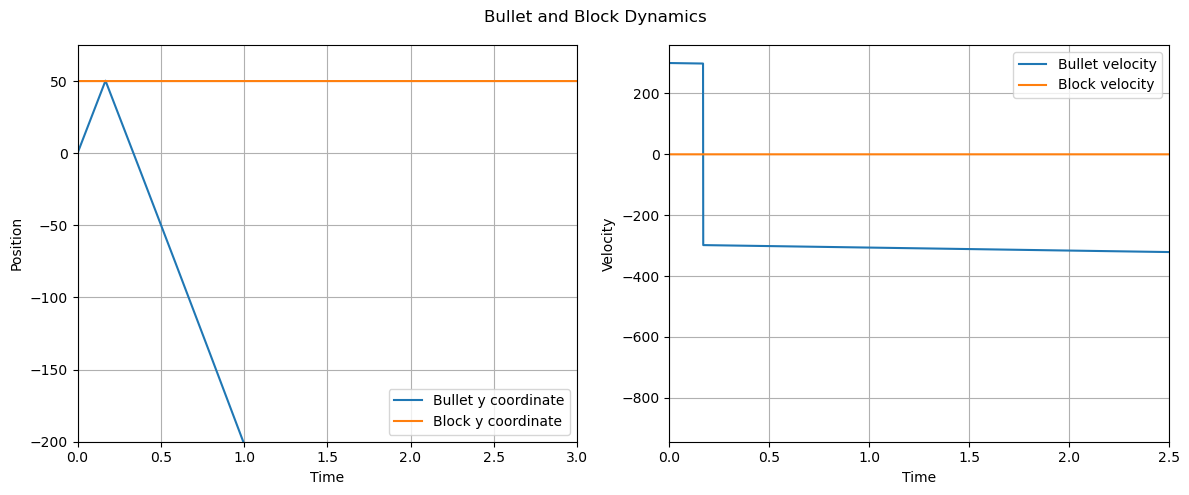

In [159]:
e = 1

for i in np.arange(len(bullet_vy)-1):
    if bullet_y[i] < block_y[i]:
        bullet_y[i+1] = bullet_y[i] + bullet_vy[i] * (t[i+1] - t[i]) + 0.5 * bullet_ay[i] * (t[i+1] - t[i])**2
        bullet_vy[i+1] = bullet_vy[i] + bullet_ay[i] * (t[i+1] - t[i])
    else: 
        bullet_vy[i+1] = -e * bullet_vy[i]
        bullet_y[i+1] = bullet_y[i] + bullet_vy[i+1] * (t[i+1] - t[i]) + 0.5 * bullet_ay[i] * (t[i+1] - t[i])**2


fig, axes = plt.subplots(1, 2, figsize=(12, 5))  
fig.suptitle('Bullet and Block Dynamics') 

axes[0].plot(t, bullet_y, label='Bullet y coordinate', color='C0') 
axes[0].plot(t, block_y, label='Block y coordinate', color='C1') 
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Position')
axes[0].set_xlim(0, 3)
axes[0].set_ylim(-200, 75)
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t, bullet_vy, label='Bullet velocity', color='C0') 
axes[1].plot(t, block_vy, label='Block velocity', color='C1')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Velocity')
axes[1].set_xlim(0, 2.5)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout(h_pad=1.0, w_pad=1.0) 
plt.show()



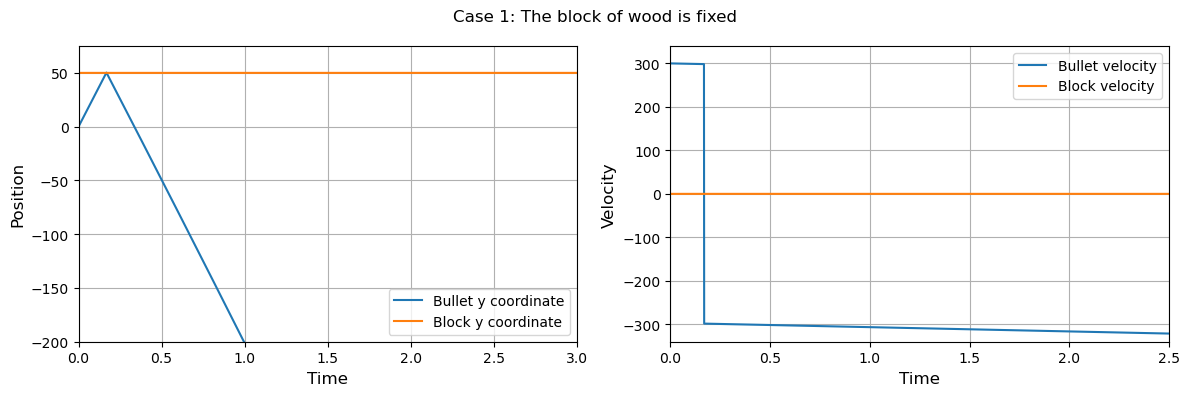

In [160]:
# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Case 1: The block of wood is fixed', fontsize=12)

# Plot for position
axes[0].plot(t, bullet_y, label='Bullet y coordinate', color='C0')
axes[0].plot(t, block_y, label='Block y coordinate', color='C1')
axes[0].set_xlabel('Time', fontsize=12)
axes[0].set_ylabel('Position', fontsize=12)
axes[0].set_xlim(0, 3)
axes[0].set_ylim(-200, 75)
axes[0].legend()
axes[0].grid(True)

# Plot for velocity
axes[1].plot(t, bullet_vy, label='Bullet velocity', color='C0')
axes[1].plot(t, block_vy, label='Block velocity', color='C1')
axes[1].set_xlabel('Time', fontsize=12)
axes[1].set_ylabel('Velocity', fontsize=12)
axes[1].set_xlim(0, 2.5)
axes[1].set_ylim(-340, 340)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout(h_pad=1.0, w_pad=1.0)
plt.savefig('Case1.png')
plt.show()


### Case 2
Block of is allowed to move. Only verically - 1DOF


$$
v_{1f} = \frac{{m_1 - m_2}}{{m_1 + m_2}} v_{1i} + \frac{{2m_2}}{{m_1 + m_2}} v_{2i}
$$

$$
v_{2f} = \frac{{2m_1}}{{m_1 + m_2}} v_{1i} + \frac{{m_2 - m_1}}{{m_1 + m_2}} v_{2i}
$$

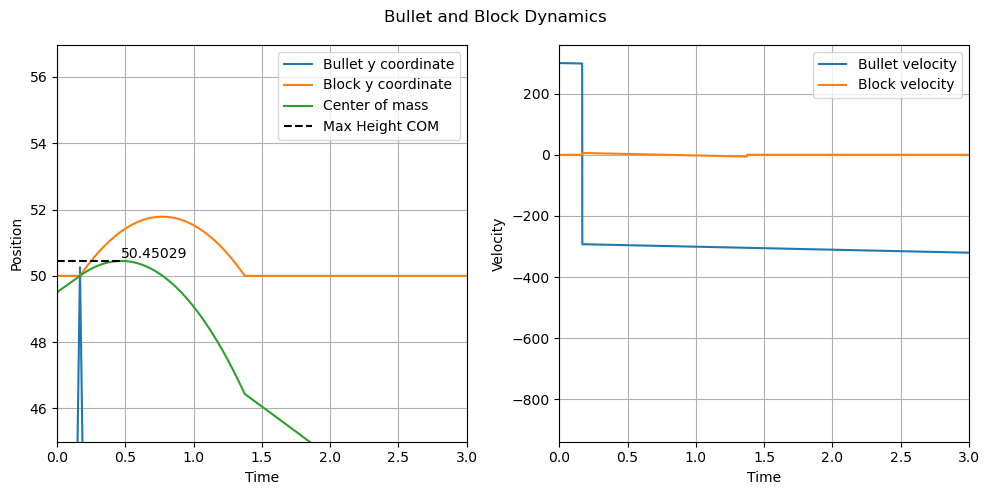

Maximum height of the center of mass is 50.45029 m.


In [161]:
# Bullet
bullet_y = np.zeros(len(t))
bullet_vy = np.zeros(len(t))
bullet_ay = np.zeros(len(t))
bullet_y[0] = IC[0]
bullet_vy[0] = IC[1]
bullet_ay[:] = -g

# Block of wood
block_y = np.zeros(len(t))
block_vy = np.zeros(len(t))
block_ay = np.zeros(len(t))
block_y[:] = IC[2]
block_vy[0] = IC[3]
block_ay[:] = -g

for i in np.arange(len(bullet_vy)-1):
    if bullet_y[i] < block_y[i]:
        bullet_y[i+1] = bullet_y[i] + bullet_vy[i] * (t[i+1] - t[i]) + 0.5 * bullet_ay[i] * (t[i+1] - t[i])**2
        bullet_vy[i+1] = bullet_vy[i] + bullet_ay[i] * (t[i+1] - t[i])
        if block_y[i] > block_y[0]:
            block_y[i+1] = block_y[i] + block_vy[i] * (t[i+1] - t[i]) + 0.5 * block_ay[i] * (t[i+1] - t[i])**2
            block_vy[i+1] = block_vy[i] + block_ay[i] * (t[i+1] - t[i])

    else: 
        bullet_vy[i+1] = ((bullet_mass - block_mass)/(bullet_mass + block_mass))* bullet_vy[i] + (2*block_mass/(bullet_mass + block_mass))*block_vy[i]
        block_vy[i+1] = (2*bullet_mass/(bullet_mass + block_mass))* bullet_vy[i] + ((block_mass - bullet_mass)/(bullet_mass + block_mass))*block_vy[i]
        bullet_y[i+1] = bullet_y[i] + bullet_vy[i+1] * (t[i+1] - t[i]) + 0.5 * bullet_ay[i] * (t[i+1] - t[i])**2
        block_y[i+1] = block_y[i] + block_vy[i+1] * (t[i+1] - t[i]) + 0.5 * block_ay[i] * (t[i+1] - t[i])**2


# Center of mass
COM = np.zeros_like(bullet_y)
COM = (bullet_mass*bullet_y + block_mass*block_y)/(bullet_mass + block_mass)

max_height = max(COM)
time_at_max_height = t[np.argmax(COM)]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))  
fig.suptitle('Bullet and Block Dynamics') 

axes[0].plot(t, bullet_y, label='Bullet y coordinate', color='C0') 
axes[0].plot(t, block_y, label='Block y coordinate', color='C1') 
axes[0].plot(t, COM, label='Center of mass', color='C2')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Position')
axes[0].set_xlim(0, 3)
axes[0].set_ylim(0.9 * min(block_y[:]), 1.1 * max(max(bullet_y[:]), max(block_y[:])))
axes[0].hlines(max(COM), 0, time_at_max_height, linestyle='--', color='black', label='Max Height COM')
axes[0].text(time_at_max_height, max(COM), f'{max(COM):.5f}', ha='left', va='bottom')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t, bullet_vy, label='Bullet velocity', color='C0') 
axes[1].plot(t, block_vy, label='Block velocity', color='C1')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Velocity')
axes[1].set_xlim(0, 3)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout(h_pad=1.0, w_pad=1.0) 
plt.show()
print(f'Maximum height of the center of mass is {max_height:.5f} m.')



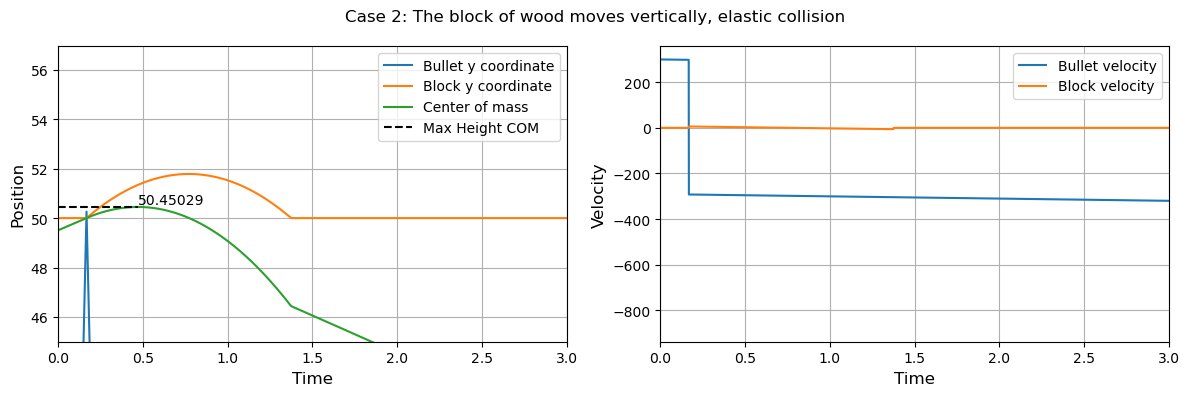

In [162]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Case 2: The block of wood moves vertically, elastic collision', fontsize=12)

# Plot for position
axes[0].plot(t, bullet_y, label='Bullet y coordinate', color='C0')
axes[0].plot(t, block_y, label='Block y coordinate', color='C1')
axes[0].plot(t, COM, label='Center of mass', color='C2')
axes[0].set_xlabel('Time', fontsize=12)
axes[0].set_ylabel('Position', fontsize=12)
axes[0].set_xlim(0, 3)
axes[0].set_ylim(0.9 * min(block_y[:]), 1.1 * max(max(bullet_y[:]), max(block_y[:])))
axes[0].hlines(max(COM), 0, time_at_max_height, linestyle='--', color='black', label='Max Height COM')
axes[0].text(time_at_max_height, max(COM), f'{max(COM):.5f}', ha='left', va='bottom')
axes[0].legend()
axes[0].grid(True)

# Plot for velocity
axes[1].plot(t, bullet_vy, label='Bullet velocity', color='C0')
axes[1].plot(t, block_vy, label='Block velocity', color='C1')
axes[1].set_xlabel('Time', fontsize=12)
axes[1].set_ylabel('Velocity', fontsize=12)
axes[1].set_xlim(0, 3)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout(h_pad=1.0, w_pad=1.0)
# plt.savefig('Case2.png')
plt.show()


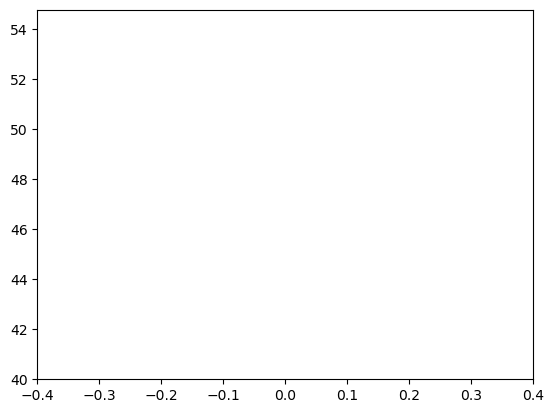

In [163]:
from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots()
ax.set_xlim(-0.4, 0.4)
ax.set_ylim(40, max(block_y) + 3)

bullet_dot, = ax.plot([], [], 'C0o', ms=3)
block_line, = ax.plot([], [], color='brown', linewidth=6)

def update(frame):
    bullet_dot.set_data(0, bullet_y[frame]) 
    block_line.set_data([-0.5 * block_length, 0.5 * block_length], [block_y[frame], block_y[frame]])
    return bullet_dot, block_line,

# ani = FuncAnimation(fig, update, frames=len(t), interval=1000/60, blit=True)

# ani.save('BandB1_elastic.gif', writer='pillow')

plt.show()

### Bullet misses the block

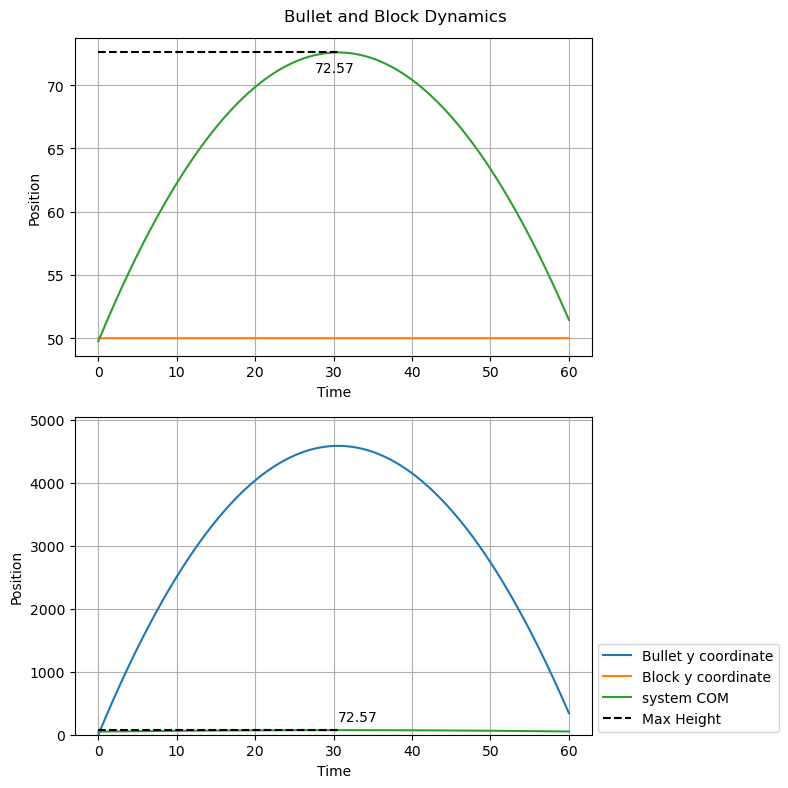

In [173]:
# Bullet
bullet_mass = 0.01
bullet_y = np.zeros(len(t))
bullet_vy = np.zeros(len(t))
bullet_ay = np.zeros(len(t))
bullet_y[0] = IC[0]
bullet_vy[0] = IC[1]
bullet_ay[:] = -g

# Block of wood
block_mass = 2.0
block_length = 0.3
block_y = np.zeros(len(t))
block_vy = np.zeros(len(t))
block_ay = np.zeros(len(t))
block_y[:] = IC[2]
block_vy[0] = IC[3]
block_ay[:] = -g

for i in np.arange(len(bullet_vy)-1):
        bullet_y[i+1] = bullet_y[i] + bullet_vy[i] * (t[i+1] - t[i]) + 0.5 * bullet_ay[i] * (t[i+1] - t[i])**2
        bullet_vy[i+1] = bullet_vy[i] + bullet_ay[i] * (t[i+1] - t[i])
    
# System center of mass
COM = np.zeros_like(bullet_y)
for i in np.arange(len(COM)):
        COM[i] = 1/(bullet_mass + block_mass) * (bullet_mass * bullet_y[i] + block_mass * block_y[i])

fig, axes = plt.subplots(2, 1, figsize=(8, 8))  
fig.suptitle('Bullet and Block Dynamics') 

max_height = max(max(bullet_y), max(block_y))
max_height_index = np.argmax(np.maximum(bullet_y, block_y))
time_at_max_height = t[max_height_index]


# axes[0].plot(t, bullet_y, label='Bullet y coordinate', color='C0') 
axes[0].plot(t, block_y, label='Block y coordinate', color='C1') 
axes[0].plot(t, COM, label='system COM', color='C2')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Position')
# axes[0].set_ylim(0, 1.1 * max(max(bullet_y[:]), max(block_y[:])))
axes[0].hlines(max(COM), 0, time_at_max_height, linestyle='--', color='black', label='Max Height')
axes[0].text(time_at_max_height-3, 0.975*max(COM), f'{max(COM):.2f}', ha='left', va='bottom')
# axes[0].legend(loc=(-1.05, 0.31))
axes[0].grid(True)

axes[1].plot(t, bullet_y, label='Bullet y coordinate', color='C0') 
axes[1].plot(t[0], block_y[0], label='Block y coordinate', color='C1') 
axes[1].plot(t, COM, label='system COM', color='C2')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Position')
axes[1].set_ylim(0, 1.1 * max(max(bullet_y[:]), max(block_y[:])))
axes[1].hlines(max(COM), 0, time_at_max_height, linestyle='--', color='black', label='Max Height')
axes[1].text(time_at_max_height, max(COM)+100, f'{max(COM):.2f}', ha='left', va='bottom')
axes[1].legend(loc=(1.01, 0.01))
axes[1].grid(True)

# axes[2].plot(t, bullet_vy, label='Bullet velocity', color='C0') 
# axes[2].plot(t, block_vy, label='Block velocity', color='C1', linestyle='--')
# axes[2].set_xlabel('Time')
# axes[2].set_ylabel('Velocity')
# axes[2].set_xlim(0, 4)
# axes[2].legend()
# axes[2].grid(True)

plt.tight_layout() 
plt.savefig('Case4.png')
plt.show()

In [165]:
max(bullet_y)

4587.155963289234

In [166]:
max(block_y)

50.0

In [167]:
X = bullet_mass * max(bullet_y) #+ block_mass * max(block_y)
X/(bullet_mass + block_mass)

22.821671459150423

In theory, the height reached by the COM should be the same in case of a perfectly elastic collision as in case where the bullet misses the block. Not sure yet, why that does not show since there is a conservation of linear momentum and kinetic energy. Probably should implement the conservation of kinetic energy in a different way.

## Plastic collision
In this scenario the bullet and the block of wood stay attached after the collision. This means they move together as one. The only rule that defines the movement is the conservation of linear momentum (since the movement is restricted to 1D, y axis)

Linear momentum is conserved at i: 168 
Right before impact: 5.967 kg m/s 
Velocity of the bullet right before impact: 298.352 m/s


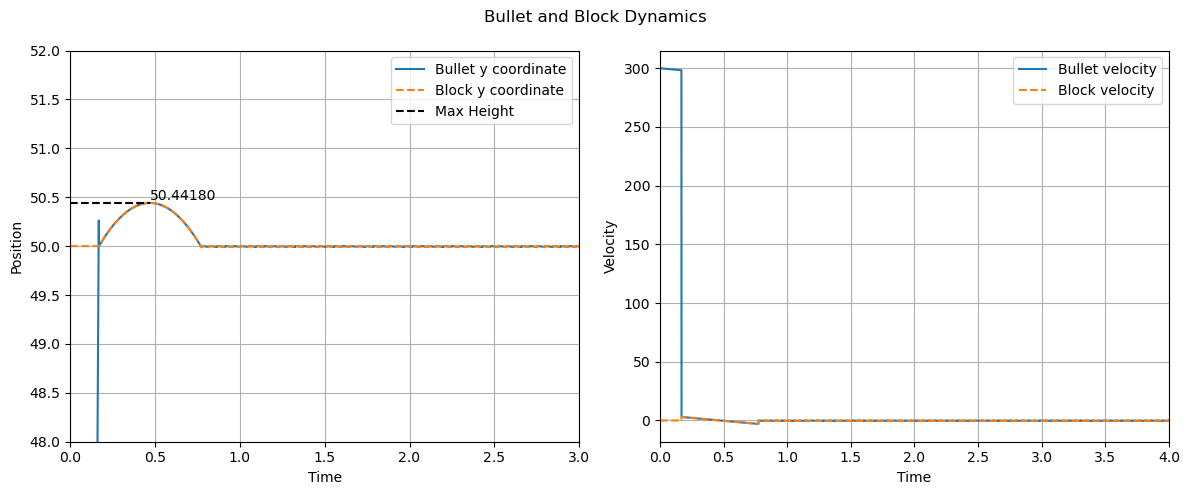

In [168]:
# Bullet
bullet_mass = 0.02
bullet_y = np.zeros(len(t))
bullet_vy = np.zeros(len(t))
bullet_ay = np.zeros(len(t))
bullet_y[0] = IC[0]
bullet_vy[0] = IC[1]
bullet_ay[:] = -g

# Block of wood
block_mass = 2.0
block_length = 0.3
block_y = np.zeros(len(t))
block_vy = np.zeros(len(t))
block_ay = np.zeros(len(t))
block_y[:] = IC[2]
block_vy[0] = IC[3]
block_ay[:] = -g

merged = False
for i in np.arange(len(bullet_vy)-1):
    if not merged and bullet_y[i] < block_y[0]:
        bullet_y[i+1] = bullet_y[i] + bullet_vy[i] * (t[i+1] - t[i]) + 0.5 * bullet_ay[i] * (t[i+1] - t[i])**2
        bullet_vy[i+1] = bullet_vy[i] + bullet_ay[i] * (t[i+1] - t[i])
        block_y[i+1] = block_y[i] + block_vy[i] * (t[i+1] - t[i]) + 0.5 * block_ay[i] * (t[i+1] - t[i])**2
        block_vy[i+1] = block_vy[i]
    elif not merged and bullet_y[i] >= block_y[0]:
        print(f'Linear momentum is conserved at i: {i} \nRight before impact: {(bullet_vy[i] * bullet_mass):.3f} kg m/s \nVelocity of the bullet right before impact: {bullet_vy[i]:.3f} m/s')
        v = (bullet_mass * bullet_vy[i] + block_mass * block_vy[i]) / (bullet_mass + block_mass)
        bullet_vy[i+1] = v
        block_vy[i+1] = v
        bullet_y[i+1] = block_y[i]
        merged = True
    elif merged and block_y[i] > block_y[0] - 0.01:
        block_vy[i+1] = block_vy[i] + block_ay[i] * (t[i+1] - t[i])
        block_y[i+1] = block_y[i] + block_vy[i+1] * (t[i+1] - t[i]) + 0.5 * block_ay[i] * (t[i+1] - t[i])**2
        bullet_vy[i+1] = bullet_vy[i] + bullet_ay[i] * (t[i+1] - t[i])
        bullet_y[i+1] = block_y[i+1]
    elif merged and block_y[i] <= block_y[0]+1:
        block_vy[i+1] = 0
        bullet_vy[i+1] = 0
        block_y[i+1] = max(block_y[i], block_y[0])
        bullet_y[i+1] = max(block_y[0], block_y[i+1])
    


fig, axes = plt.subplots(1, 2, figsize=(12, 5))  
fig.suptitle('Bullet and Block Dynamics') 

max_height = max(max(bullet_y), max(block_y))
max_height_index = np.argmax(np.maximum(bullet_y, block_y))
time_at_max_height = t[max_height_index]


axes[0].plot(t, bullet_y, label='Bullet y coordinate', color='C0') 
axes[0].plot(t, block_y, label='Block y coordinate', color='C1', linestyle='--') 
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Position')
axes[0].set_xlim(0, 3)
axes[0].set_ylim(48, 52)
axes[0].hlines(max_height, 0, time_at_max_height, linestyle='--', color='black', label='Max Height')
axes[0].text(time_at_max_height, max_height, f'{max_height:.5f}', ha='left', va='bottom')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t, bullet_vy, label='Bullet velocity', color='C0') 
axes[1].plot(t, block_vy, label='Block velocity', color='C1', linestyle='--')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Velocity')
axes[1].set_xlim(0, 4)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout(h_pad=1.0, w_pad=1.0) 
plt.show()


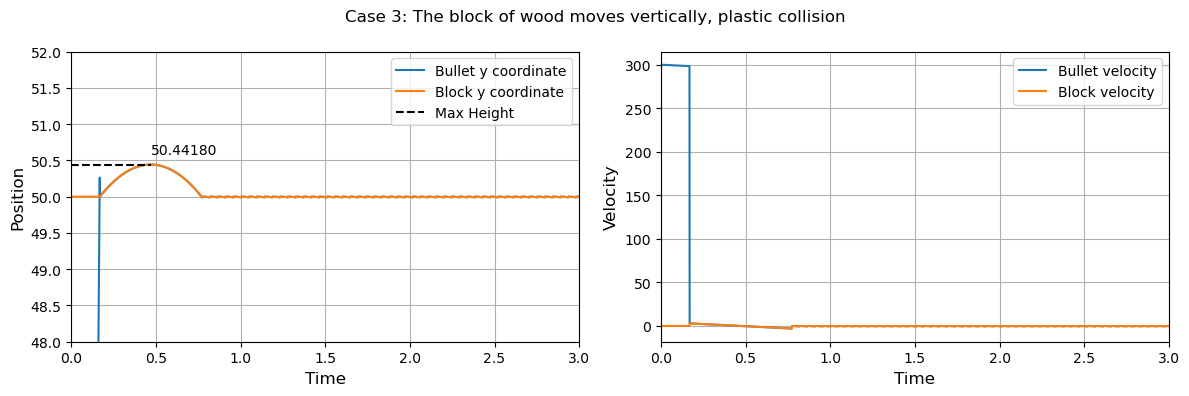

In [169]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Case 3: The block of wood moves vertically, plastic collision', fontsize=12)

# Plot for position
axes[0].plot(t, bullet_y, label='Bullet y coordinate', color='C0')
axes[0].plot(t, block_y, label='Block y coordinate', color='C1')
# axes[0].plot(t, COM, label='Center of mass', color='C2')
axes[0].set_xlabel('Time', fontsize=12)
axes[0].set_ylabel('Position', fontsize=12)
axes[0].set_xlim(0, 3)
axes[0].set_ylim(48, 52)
axes[0].hlines(max_height, 0, time_at_max_height, linestyle='--', color='black', label='Max Height')
axes[0].text(time_at_max_height, 1.002*max_height, f'{max_height:.5f}', ha='left', va='bottom')
axes[0].legend()
axes[0].grid(True)

# Plot for velocity
axes[1].plot(t, bullet_vy, label='Bullet velocity', color='C0')
axes[1].plot(t, block_vy, label='Block velocity', color='C1')
axes[1].set_xlabel('Time', fontsize=12)
axes[1].set_ylabel('Velocity', fontsize=12)
axes[1].set_xlim(0, 3)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout(h_pad=1.0, w_pad=1.0)
# plt.savefig('Case3.png')
plt.show()


As I conclude this mini project, there are several areas I would like to explore further. Firstly, investigating why kinetic energy conservation may not be working as expected. Additionally, I would like to consider adding bouncing behavior when bodies reach their starting altitude. Exploring a 2D approach and precise center impacts are also on my radar. Moreover, simulating scenarios with supported bodies presents interesting possibilities. Finally, understanding how collisions impact initial behavior remains a focus. Stay tuned on GitHub for updates and future developments on this project.

In [170]:
print("done")

done
